In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import jax
import jax.numpy as jnp
import optax
from scipy.spatial import cKDTree
%matplotlib widget

In [2]:
s11_transmitter = np.loadtxt(   '/Users/dominiv/research/data/S11_Transmitter.csv', delimiter=',', skiprows=1)
s11_aut = np.loadtxt( '/Users/dominiv/research/data/S11_AUT.csv', delimiter=',', skiprows=1)
s12_atu_t = np.loadtxt('/Users/dominiv/research/data/S12_AUT_to_Trans.csv', delimiter=',', skiprows=1)
inc = 201
ang = 361
print(s11_transmitter.shape)

(72561, 4)


In [3]:
gain_100 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_100MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_150 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_150MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_200 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_200MHz_LinearScale.csv', delimiter=',', skiprows=1)
gain_250 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_at_250MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_100 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_100MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_150 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_150MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_200 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_200MHz_LinearScale.csv', delimiter=',', skiprows=1)
dipole_gain_250 = np.loadtxt('/Users/dominiv/research/data/3D_Realized_Gain_Plot_dipole_at_250MHz_LinearScale.csv', delimiter=',', skiprows=1)

In [4]:
nside = 32
npix = hp.nside2npix(nside)
beam_thetas = np.deg2rad(gain_100[:, 1])
beam_phis =   np.deg2rad(gain_100[:, 0])

# theta, phi, gain_lin = ...  (1D arrays)

# Sample unit vectors: shape (Nsamp, 3)
def hfss_map(gain):
    sample_vec = np.asarray(hp.ang2vec(beam_thetas, beam_phis))
    if sample_vec.shape[0] == 3 and sample_vec.ndim == 2:
        sample_vec = sample_vec.T
    
    tree = cKDTree(sample_vec)
    
    pix_vec = np.asarray(hp.pix2vec(nside, np.arange(npix))).T
    
    k = 8
    dist, idx = tree.query(pix_vec, k=k)
    
    if k == 1:
        dist = dist[:, None]
        idx = idx[:, None]
    
    eps = 1e-12
    w = 1.0 / (dist + eps)**2
    w /= w.sum(axis=1, keepdims=True)
    
    hmap = (w * gain[:, 2][idx]).sum(axis=1)
    return hmap

beam_100 = hfss_map(gain_100)
beam_150 = hfss_map(gain_150)
beam_200 = hfss_map(gain_200)
beam_250 = hfss_map(gain_250)

dipole_beam_100 = hfss_map(dipole_gain_100)
dipole_beam_150 = hfss_map(dipole_gain_150)
dipole_beam_200 = hfss_map(dipole_gain_200)
dipole_beam_250 = hfss_map(dipole_gain_250)

In [5]:
phis =   np.deg2rad(s11_transmitter[:, 0][::inc])
thetas = np.deg2rad(s11_transmitter[:, 1][::inc])
freqs = s11_transmitter[:inc, 2]

def db_lin(db):
    # return 10**(db/10)
    return db

s11_t = db_lin(s11_transmitter[:, 3])
s11_t = s11_t.reshape(ang, inc)
# s11_t = np.reshape(s11_t, newshape=(inc, s11_t.shape[0]//inc))

s11_bowtie = db_lin(s11_aut[:, 3])
s11_bowtie = s11_bowtie.reshape(ang, inc)
# s11_bowtie = np.reshape(s11_bowtie, newshape=(inc, s11_bowtie.shape[0]//inc))

s12_bowtie = db_lin(s12_atu_t[:, 3])
s12_bowtie = s12_bowtie.reshape(ang, inc)
# s12_bowtie = np.reshape(s12_bowtie, newshape=(inc, s12_bowtie.shape[0]//inc))
phis.shape, thetas.shape, freqs.shape, s11_t.shape, s11_bowtie.shape, s12_bowtie.shape

((361,), (361,), (201,), (361, 201), (361, 201), (361, 201))

In [6]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo
import os
mtn_tzone = ZoneInfo("America/Denver")

t_start = datetime(2025, 7, 20, 13, 11, 51, 774738, tzinfo=mtn_tzone)
t_stop =  datetime(2025, 7, 20, 14, 35, 41, 181442, tzinfo=mtn_tzone)
def unix_time_to_local(unix_times):
    local_times = np.array([datetime.fromtimestamp(ts, tz=timezone.utc).astimezone(mtn_tzone) for ts in unix_times])
    return local_times

dtype_r = jnp.float64
DEFAULT_NSIDE = 32
DEFAULT_NPIX = healpy.nside2npix(DEFAULT_NSIDE)
px = jnp.arange(DEFAULT_NPIX)
th, phi = healpy.pix2ang(DEFAULT_NSIDE, px)
DEFAULT_BEAM_TH = jnp.cos(th)**2 * jnp.cos(phi)**2
DEFAULT_BEAM_PHI = jnp.cos(th)**2 * jnp.sin(phi)**2

NameError: name 'healpy' is not defined

In [7]:
npz_file = '/Users/dominiv/eigsep/data/all_ant_2.npz'
# dtype_r = np.float32
dtype_c = np.complex64
if not os.path.exists(npz_file):
    data = {}
    times = []
    for f in files:
        print(f)
        hdr = read_header(f)
        if unix_time_to_local(hdr['times'][-1:]) < t_start:
            continue
        if unix_time_to_local(hdr['times'][:1]) > t_stop:
            continue
        dat, hdr, meta = io.read_hdf5(f)
        times.append(hdr['times'])
        for k in dat.keys():
            _d = dat[k]
            data[k] = data.get(k, []) + [_d]
    for k, v in data.items():
        data[k] = np.concatenate(v, dtype=dtype_r if len(k) == 1 else dtype_c)
    times = np.concatenate(times)
    local_times = unix_time_to_local(times)
    np.savez(npz_file, times=times, local_times=local_times, freqs=freqs, **data)
else:
    npz = np.load(npz_file, allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    times = data.pop('times')
    local_times = data.pop('local_times')
    freqs = data.pop('freqs')

In [8]:
chs = np.arange(16, 1024, 16)
k_1 = '2'
reduced = data[k_1][:, chs]
reduced = data[k_1][:,chs] - 0.5 * (data[k_1][:,chs-1] + data[k_1][:,chs+1])

In [9]:
f_ind = 44
# f_ind = 52
# f_ind = 61
ch = f_ind
AZ_STEPS = 72  # with endpoint=True
period = 68.78
#t_start = 1753038750 # s utc
t_start = 1753038750 + period/2 # s utc
# t_start = times[0] + period/2 # s utc
t_cut = [(1753039060, 1753039181), (1753042808, 1753042834), (1753043111, 1753043119)]  # junk data
i_start = np.searchsorted(times, t_start)
norm = 1 / np.mean(reduced[:i_start], axis=0, keepdims=True)
norm[:,:4] = 0
t_stop = t_start + AZ_STEPS * period
i_stop = np.searchsorted(times, t_stop)

valid = np.ones(times.shape, dtype=bool)
valid = np.where(reduced[:,52] * norm[:,52] < 1e-4, False, ~np.isnan(reduced[:,52]))
for ti, tj in t_cut:
    i, j = np.searchsorted(times, ti), np.searchsorted(times, tj)
    valid[i:j] = False
    
valid[1:-1] = np.logical_and(valid[1:-1], np.logical_and(valid[:-2], valid[2:]))
sl = slice(i_start, i_stop)
_times = times[sl].copy()
_times -= _times[0]
# optional for strictly data-driven double-period folding
#_times_rnd = np.floor(_times / (2 * period))
#_times_mod = _times - _times_rnd * (2 * period)
val = valid[sl]
print(freqs[::16][ch])

171.875


In [10]:
import aipy
class BeamFit:
    def __init__(self, times, az_steps=AZ_STEPS, lmax=5):
        self.az_steps = az_steps
        self.times = times
        self.lmax = lmax
        self._el_ax = self._ant_pvec = np.array([1, 0, 0], dtype=dtype_r)
        self._az_ax = np.array([0, 0, -1], dtype=dtype_r)
        self.prms = {}
        self.ant_pvec = self.polresp = self.A_Ylm = self.A = None

    def _set_timing_params(self, prms):
        keys = {'t_off', 'el_off', 't_az_step', 'period'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.az_deg = self.el_deg = self.ant_pvec = self.A_Ylm = self.A = None

    def _set_pol_params(self, prms):
        keys = {'prz', 'px', 'py'}
        for k in keys:
            if k in prms and prms[k] != self.prms.get(k, None):
                self.prms[k] = prms[k]
                self.gnd_pvecs = self.polresp = self.A = None

    def set_params(self, prms):
        self._set_timing_params(prms)
        self._set_pol_params(prms)
        
    def build_az_el(self):
        '''Build az/el coordinates.'''
        if self.ant_pvec is not None:
            return
        az, el, inds = [], [], []
        t_off, el_off, t_az_step, period = self.prms['t_off'], self.prms['el_off'], self.prms['t_az_step'], self.prms['period']
        i = 0
        t_i = self.times[0] + t_off
        for cnt, _az in enumerate(np.linspace(-180, 180, self.az_steps, endpoint=True)):
            t_f = t_i + period
            while i < self.times.size and self.times[i] < t_f - t_az_step:
                az.append(_az)
                if cnt % 2 == 0:
                    el.append(-180 + 360 * (self.times[i] - t_i) / (period - t_az_step))
                else:
                    el.append( 180 - 360 * (self.times[i] - t_i) / (period - t_az_step))
                inds.append(i)
                i += 1
            while i < self.times.size and self.times[i] < t_f:
                az.append(_az + (360 / (self.az_steps - 1)) * (self.times[i] - (t_f - t_az_step))/t_az_step)
                el.append(el[-1])
                inds.append(i)
                i += 1
            t_i = t_f
        self.az_deg = np.array(az)
        self.el_deg = np.array(el) + el_off
        self.inds = np.array(inds)
        rot_az = aipy.coord.rot_m(np.deg2rad(self.az_deg), self._az_ax)
        rot_el = aipy.coord.rot_m(np.deg2rad(self.el_deg), self._el_ax)
        self.ant_pvec = np.einsum('pab,pbc,c->pa', rot_el, rot_az, self._ant_pvec)

    


    
    def build_pol_resp(self):
        self.build_az_el()
        if self.polresp is not None:
            return
        pvec = np.array([[self.prms['px'], 0, 0], [0, self.prms['py'], 0]], dtype=dtype_r)
        rot_m = aipy.coord.rot_m(np.deg2rad(self.prms['prz']), np.array([0, 0, 1])).astype(dtype_r)
        self.gnd_pvecs = np.dot(rot_m, pvec.T).T
        if self.gnd_pvecs.ndim == 1:
            self.gnd_pvecs = self.gnd_pvecs[None, :]
        resp = np.dot(self.ant_pvec, self.gnd_pvecs.T)
        self.polresp = np.sum(np.abs(resp)**2, axis=-1)

    def build_A_Ylm(self):
        self.build_az_el()
        if self.A_Ylm is not None:
            return
        phi = np.deg2rad(self.az_deg)
        theta = np.deg2rad(self.el_deg)
        theta = np.mod(theta, 2*np.pi)
        theta = np.where(theta > np.pi, 2*np.pi - theta, theta)
        phi = np.mod(phi, 2*np.pi)
    
        N = theta.size
        P = (self.lmax + 1)**2
        A = np.empty((N, P), dtype=dtype_r)
    
        # Keep track of which column corresponds to which (l,m,kind)
        # kind ∈ {'m0','c','s'} for m=0, cos-like, sin-like
        self._meta = []
        col = 0
        for ell in range(self.lmax + 1):
            # m = 0 term (purely real)
            Y_l0 = sph_harm(0, ell, phi, theta).real
            #Y_l0 *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
            A[:, col] = Y_l0
            self._meta.append((ell, 0, 'm0'))
            col += 1
    
            # m > 0 terms: sqrt(2)*Re and sqrt(2)*Im
            for m in range(1, ell + 1):
                Y_lm = sph_harm(m, ell, phi, theta)  # complex
                #Y_lm *= gen_pol_resp(az_deg, el_deg, gnd_pvecs)
                A[:, col] = SQRT2 * Y_lm.real
                A[:, col+1] = SQRT2 * Y_lm.imag
                self._meta.append((ell, m, 'c'))
                self._meta.append((ell, m, 's'))
                col += 2
    
        assert col == P
        self.A_Ylm = A

    def build_A(self):
        self.build_pol_resp()
        self.build_A_Ylm()
        if self.A is not None:
            return
        self.A = self.A_Ylm * self.polresp[:, None]

    def _realcoeff_to_alm(self, coeff):
        """
        Convert real-basis coeffficients (matching design-matrix columns) into a
        healpy alm array (complex, m>=0). For a real sky, alms obey:
          a_{l,-m} = (-1)^m a_{l m}^*
        We only fill m>=0 as healpy expects.
        """
        alm = np.zeros(Alm.getsize(self.lmax), dtype=dtype_c)
        for k, (ell, m, kind) in enumerate(self._meta):
            if m == 0 and kind == 'm0':
                alm[Alm.getidx(self.lmax, ell, 0)] = coeff[k]
            elif kind in ('c'):
                c = coeff[k]
                s = coeff[k + 1]
                a_lm = (c - 1j * s) / SQRT2
                alm[Alm.getidx(self.lmax, ell, m)] = a_lm
        return alm

    def fit_alms(self, ymeas, w=None, reg=None, rcond=1e-10):
        self.build_A()
    
        # Apply weights (as sqrt weights on rows)
        ymeas = ymeas[self.inds]
        if w is None:
            w = np.ones_like(ymeas)
        else:
            w = w[self.inds]
        sqrtw = np.sqrt(w)
        Aw = self.A * sqrtw[:, None]
        yw = ymeas * sqrtw
    
        # Optional ridge regularization: stack sqrt(reg)*I
        if reg is not None and reg > 0:
            P = self.A.shape[1]
            Aw = np.vstack([Aw, np.sqrt(reg) * np.eye(P)])
            yw = np.concatenate([yw, np.zeros(P)])
    
        coeff = np.linalg.lstsq(Aw[self.inds], yw[self.inds], rcond=rcond)[0]
        yhat = self.A @ coeff
        chisq = np.sum(w * (ymeas[self.inds] - yhat[self.inds])**2)
        alm = self._realcoeff_to_alm(coeff)
        return alm, chisq, yhat

In [11]:
t_az_step = 1.7
prms = dict(
    t_az_step = t_az_step, # XXX degenerate with beam width, need empirical measurement
    t_off = -2.4 + t_az_step/2,
    # t_off = -2.0 + t_az_step/2,
    el_off = -4.0,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # el_off = -8.5,  # shift for pol_ang=62 on ch=44, seems to work for the rest. XXX degenerate with t_off?
    # az_off is unnecessary given fitting of polarization angle
    prz = 0.0,
    px = 1.0,
    py = 0.0,
    period = period,
)

# # force a rebuild
# fitter.ant_pvec = None
# fitter.az_deg = None
# fitter.el_deg = None
# fitter.A_Ylm = None
# fitter.A = None
# fitter.build_az_el()

fitter = BeamFit(_times[val])
fitter.set_params(prms)
fitter.build_az_el()

In [12]:
shift = 12
rot = reduced[:, shift:][sl][val][fitter.inds] #* norm[:, ch]
norm = norm[:, shift:]
outfile = 'figures/'
print(rot.shape, norm.shape)

(4409, 51) (1, 51)


In [13]:
az_inds = np.deg2rad(fitter.az_deg[fitter.inds])
el_inds = np.deg2rad(fitter.el_deg[fitter.inds])

In [14]:
all_inds = len(az_inds)

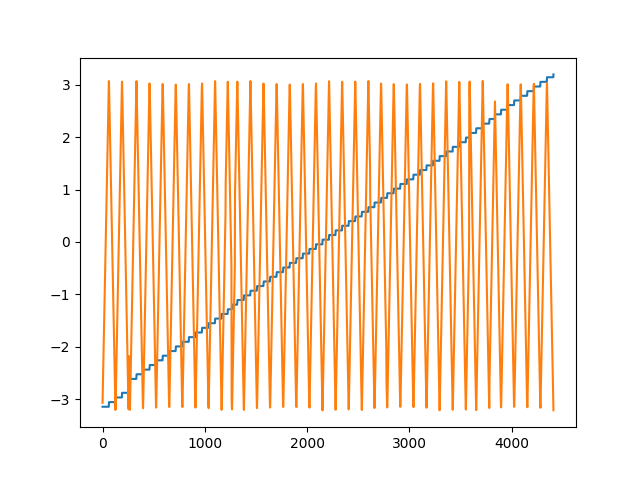

In [15]:
plt.figure()
plt.plot(az_inds)
plt.plot(el_inds)
plt.show()

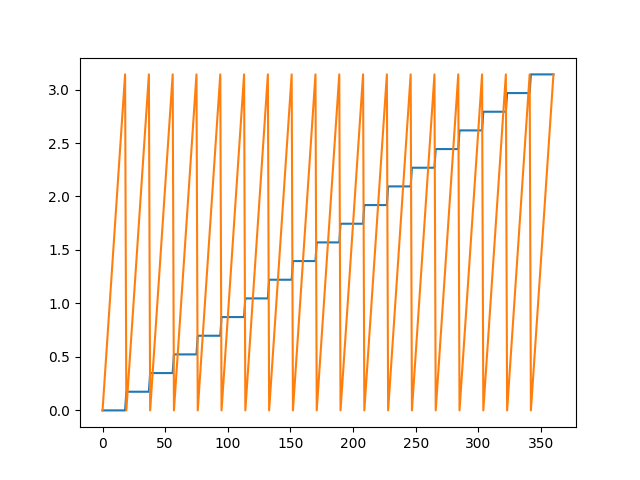

In [16]:
plt.figure()
plt.plot(phis)
plt.plot(thetas)
plt.show()

In [17]:
import numpy as np

def wrap_pi(a):
    a = np.asarray(a, float)
    return (a + np.pi) % (2*np.pi) - np.pi

def wrap_0_2pi(a):
    a = np.asarray(a, float)
    return a % (2*np.pi)

def ang_diff_pi(a, b):
    # smallest signed diff a-b in [-pi, pi)
    return wrap_pi(a - b)

def match_sim_to_meas(
    az_sim, el_sim,        # shape (Nsim,)
    az_meas, el_meas,      # shape (Nmeas,)
    tol_deg=3.0
):
    tol = np.deg2rad(tol_deg)

    azS = wrap_pi(az_sim)
    elS = np.asarray(el_sim, float)          # sim: 0..pi

    azM = wrap_pi(az_meas)
    elM = wrap_0_2pi(el_meas)                # meas: -pi..pi  -> 0..2pi

    # pairwise diffs (Nmeas, Nsim)
    daz = ang_diff_pi(azM[:, None], azS[None, :])
    delv = elM[:, None] - elS[None, :]

    ok = (np.abs(daz) <= tol) & (np.abs(delv) <= tol)

    sim_to_meas = np.full(len(azS), -1, dtype=int)

    for j in range(len(azS)):                       # one best match per sim point
        cand = np.where(ok[:, j])[0]
        if cand.size == 0:
            continue
        d = np.hypot(daz[cand, j], delv[cand, j])   # combined angular distance
        sim_to_meas[j] = cand[np.argmin(d)]

    matched_sim = np.where(sim_to_meas != -1)[0]
    matched_meas = sim_to_meas[matched_sim]
    missing_sim = np.where(sim_to_meas == -1)[0]

    return matched_sim, matched_meas, missing_sim

matched_sim, matched_meas, missing_sim = match_sim_to_meas(
    az_sim=phis, el_sim=thetas,
    az_meas=az_inds, el_meas=el_inds,
    tol_deg=3.0
)

print("matched:", len(matched_sim), "of", len(phis))
print("missing simulated angles:", len(missing_sim))


matched: 346 of 361
missing simulated angles: 15


In [18]:
import numpy as np

def stats(name, a):
    a = np.asarray(a, float)
    print(f"{name}: shape={a.shape}, min={a.min():.4f}, max={a.max():.4f}")

stats("az_inds", az_inds)
stats("el_inds", el_inds)
stats("phis", phis)
stats("thetas", thetas)
print("π =", np.pi)

keep = (el_inds >= 0) & (el_inds <= np.pi)
az_m = az_inds[keep]
el_m = el_inds[keep]

def wrap_pi(a):
    a = np.asarray(a, float)
    return (a + np.pi) % (2*np.pi) - np.pi

def match_sim_to_meas_angles(phis, thetas, az_m, el_m, tol_deg=3.0):
    tol = np.deg2rad(tol_deg)

    azS = wrap_pi(phis)
    elS = np.asarray(thetas, float)

    azM = wrap_pi(az_m)
    elM = np.asarray(el_m, float)

    # pairwise diffs (Nmeas, Nsim)
    daz = np.abs(wrap_pi(azM[:, None] - azS[None, :]))
    delv = np.abs(elM[:, None] - elS[None, :])

    ok = (daz <= tol) & (delv <= tol)

    sim_to_meas = np.full(len(azS), -1, dtype=int)
    best_daz = np.full(len(azS), np.nan)
    best_del = np.full(len(azS), np.nan)

    for j in range(len(azS)):
        cand = np.where(ok[:, j])[0]
        if cand.size == 0:
            continue
        d = np.hypot(daz[cand, j], delv[cand, j])
        k = cand[np.argmin(d)]
        sim_to_meas[j] = k
        best_daz[j] = daz[k, j]
        best_del[j] = delv[k, j]

    matched = np.where(sim_to_meas != -1)[0]
    missing = np.where(sim_to_meas == -1)[0]
    return matched, sim_to_meas[matched], missing, best_daz[matched], best_del[matched]

matched_sim, matched_meas, missing_sim, az_err, el_err = match_sim_to_meas_angles(
    phis, thetas, az_m, el_m, tol_deg=3.0
)

print("matched:", len(matched_sim), "of", len(phis))
print("missing:", len(missing_sim))

print("az error: median/max (deg):",
      np.rad2deg(np.median(az_err)), np.rad2deg(np.max(az_err)))
print("el error: median/max (deg):",
      np.rad2deg(np.median(el_err)), np.rad2deg(np.max(el_err)))

show = matched_sim[:10]
print(np.column_stack([
    np.rad2deg(wrap_pi(phis[show])),
    np.rad2deg(thetas[show]),
    np.rad2deg(wrap_pi(az_m[matched_meas[:10]])),
    np.rad2deg(el_m[matched_meas[:10]]),
    np.rad2deg(az_err[:10]),
    np.rad2deg(el_err[:10]),
]))
# columns: sim_az, sim_el, meas_az, meas_el, az_err, el_err



az_inds: shape=(4409,), min=-3.1416, max=3.1957
el_inds: shape=(4409,), min=-3.2112, max=3.0713
phis: shape=(361,), min=0.0000, max=3.1416
thetas: shape=(361,), min=0.0000, max=3.1416
π = 3.141592653589793
matched: 327 of 361
missing: 34
az error: median/max (deg): 1.2676056338028132 2.9577464788732564
el error: median/max (deg): 1.2307344924374841 2.8673313188386285
[[ 0.00000000e+00  0.00000000e+00 -2.53521127e+00  4.13153694e-01
   2.53521127e+00  4.13153694e-01]
 [ 0.00000000e+00  1.00000000e+01  2.53521127e+00  8.54946992e+00
   2.53521127e+00  1.45053008e+00]
 [ 0.00000000e+00  2.00000000e+01  2.53521127e+00  2.00744266e+01
   2.53521127e+00  7.44265589e-02]
 [ 0.00000000e+00  3.00000000e+01 -2.53521127e+00  2.92255472e+01
   2.53521127e+00  7.74452786e-01]
 [ 0.00000000e+00  4.00000000e+01 -2.53521127e+00  4.07505039e+01
   2.53521127e+00  7.50503854e-01]
 [ 0.00000000e+00  5.00000000e+01  2.53521127e+00  4.88868188e+01
   2.53521127e+00  1.11318120e+00]
 [ 0.00000000e+00  6.000

matched: 327 of 361 | missing: 34 | tol: 3.0°
az error median/max (deg): 1.2676056338028132 2.9577464788732564
el error median/max (deg): 1.2307344924374841 2.8673313188386285


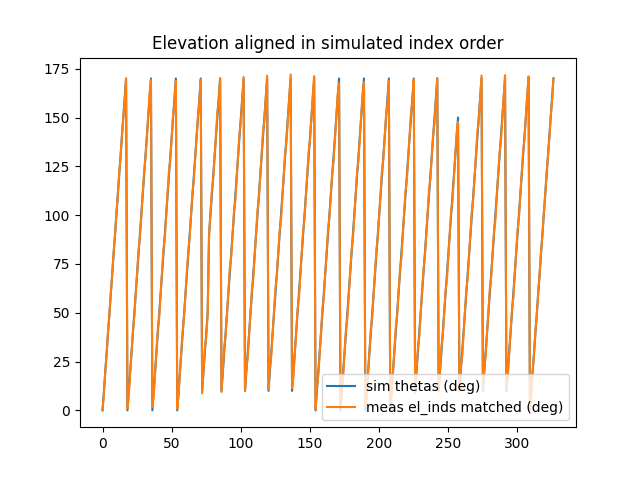

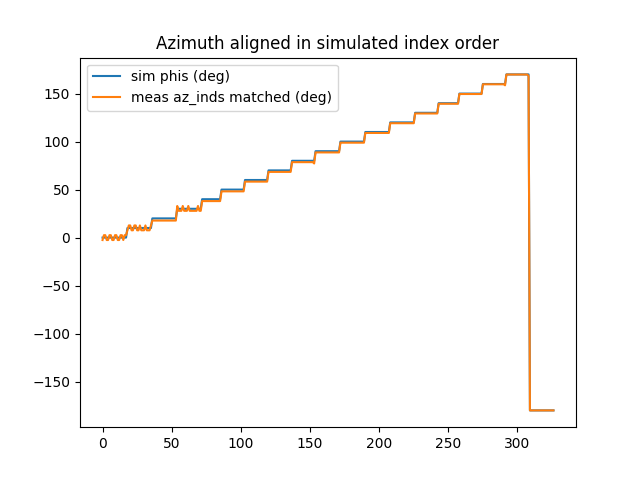

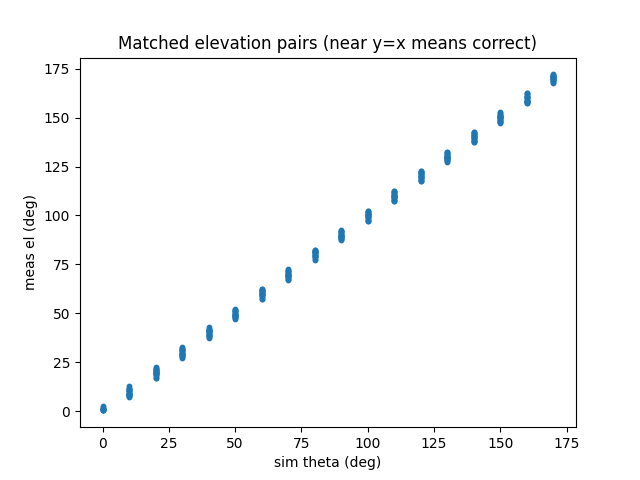

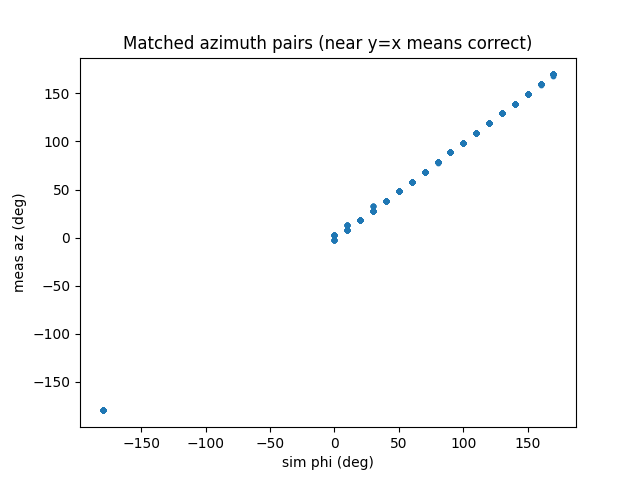

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --------- CONFIG ----------
tol_deg = 3.0  # matching tolerance in degrees
# ---------------------------

def wrap_pi(a):
    a = np.asarray(a, float)
    return (a + np.pi) % (2*np.pi) - np.pi

# 1) Filter measured to simulated elevation domain [0, pi]
keep = (el_inds >= 0) & (el_inds <= np.pi)
az_m = az_inds[keep]
el_m = el_inds[keep]
meas_map = np.where(keep)[0]  # filtered index -> original index

# 2) Match: for each sim point, pick closest measured point within tolerance
tol = np.deg2rad(tol_deg)

azS = wrap_pi(phis)
elS = np.asarray(thetas, float)

azM = wrap_pi(az_m)
elM = np.asarray(el_m, float)

daz = np.abs(wrap_pi(azM[:, None] - azS[None, :]))  # (Nmeas, Nsim)
delv = np.abs(elM[:, None] - elS[None, :])

ok = (daz <= tol) & (delv <= tol)

sim_to_meas_f = np.full(len(azS), -1, dtype=int)
best_daz = np.full(len(azS), np.nan)
best_del = np.full(len(azS), np.nan)

for j in range(len(azS)):
    cand = np.where(ok[:, j])[0]
    if cand.size == 0:
        continue
    d = np.hypot(daz[cand, j], delv[cand, j])
    k = cand[np.argmin(d)]
    sim_to_meas_f[j] = k
    best_daz[j] = daz[k, j]
    best_del[j] = delv[k, j]

matched_sim = np.where(sim_to_meas_f != -1)[0]
matched_meas = meas_map[sim_to_meas_f[matched_sim]]  # ORIGINAL measured indices
missing_sim = np.where(sim_to_meas_f == -1)[0]

# 3) Sort by simulated index so "index plots" make sense
order = np.argsort(matched_sim)
ms = matched_sim[order]
mm = matched_meas[order]

# 4) Report + plots
print(f"matched: {len(ms)} of {len(phis)} | missing: {len(missing_sim)} | tol: {tol_deg}°")
az_err = np.abs(wrap_pi(az_inds[mm] - phis[ms]))
el_err = np.abs(el_inds[mm] - thetas[ms])
print("az error median/max (deg):", np.rad2deg(np.median(az_err)), np.rad2deg(np.max(az_err)))
print("el error median/max (deg):", np.rad2deg(np.median(el_err)), np.rad2deg(np.max(el_err)))

# A) The index-ordered overlay you expected
plt.figure()
plt.plot(np.rad2deg(thetas[ms]), label="sim thetas (deg)")
plt.plot(np.rad2deg(el_inds[mm]), label="meas el_inds matched (deg)")
plt.legend(); plt.title("Elevation aligned in simulated index order"); plt.show()

plt.figure()
plt.plot(np.rad2deg(wrap_pi(phis[ms])), label="sim phis (deg)")
plt.plot(np.rad2deg(wrap_pi(az_inds[mm])), label="meas az_inds matched (deg)")
plt.legend(); plt.title("Azimuth aligned in simulated index order"); plt.show()

# B) The strongest validity check: scatter should sit near diagonal
plt.figure()
plt.scatter(np.rad2deg(thetas[ms]), np.rad2deg(el_inds[mm]), s=10)
plt.xlabel("sim theta (deg)"); plt.ylabel("meas el (deg)")
plt.title("Matched elevation pairs (near y=x means correct)"); plt.show()

plt.figure()
plt.scatter(np.rad2deg(wrap_pi(phis[ms])), np.rad2deg(wrap_pi(az_inds[mm])), s=10)
plt.xlabel("sim phi (deg)"); plt.ylabel("meas az (deg)")
plt.title("Matched azimuth pairs (near y=x means correct)"); plt.show()


In [20]:
matched_sim = s12_bowtie[ms, :]
matched_rot = rot[mm, :]
matched_rot.shape, matched_sim.shape

((327, 51), (327, 201))

In [21]:
freqs[::16][26]
freqs[16*26]

101.5625

In [22]:
norm.shape

(1, 51)

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_42161/3052670892.py:2: RuntimeWarning: invalid value encountered in log10
  plt.plot(10*np.log10(matched_rot[:, 26]))


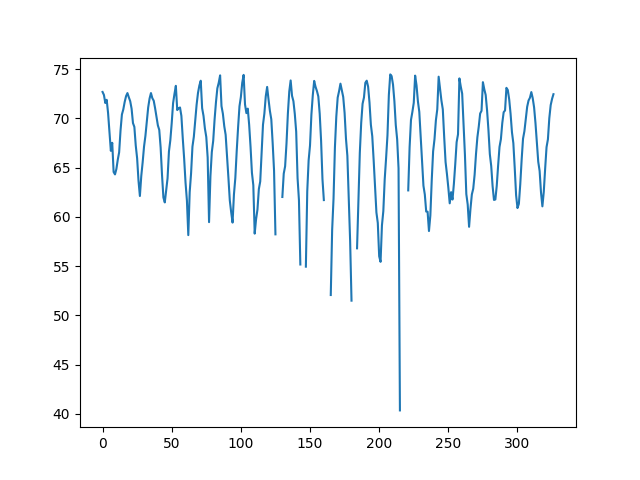

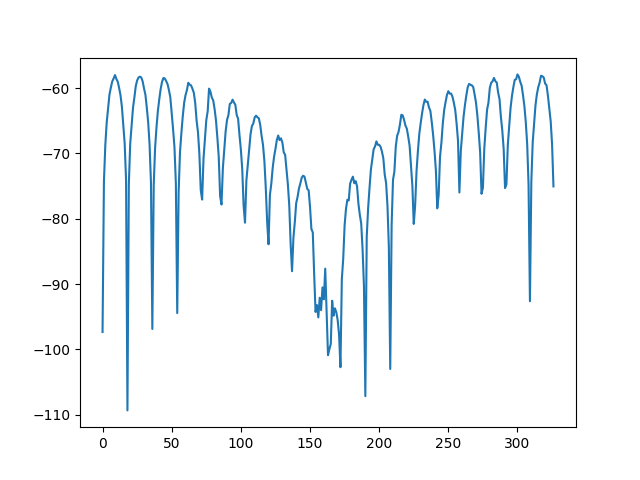

In [23]:
plt.figure()
plt.plot(10*np.log10(matched_rot[:, 26]))
plt.show()
plt.figure()
# plt.plot(10**(matched_sim[:, 50]/10))
plt.plot((matched_sim[:, 50]))
plt.show()

In [24]:
import numpy as np

def wrap_pi(a):
    a = np.asarray(a, float)
    return (a + np.pi) % (2*np.pi) - np.pi

def ang_dist(phi1, th1, phi2, th2):
    """Great-circle distance between (phi,theta) points on sphere (radians)."""
    # Convert to unit vectors using healpy-style: theta=colatitude, phi=longitude
    x1 = np.sin(th1) * np.cos(phi1); y1 = np.sin(th1) * np.sin(phi1); z1 = np.cos(th1)
    x2 = np.sin(th2) * np.cos(phi2); y2 = np.sin(th2) * np.sin(phi2); z2 = np.cos(th2)
    dot = x1*x2 + y1*y2 + z1*z2
    return np.arccos(np.clip(dot, -1.0, 1.0))

# ---- Choose what you want the "start" to be ----
# Center of Mollweide:
# phi_ref  = 0.0
# theta_ref = np.pi/2

# If you instead want "bottom" start (south pole), use:
phi_ref = 0.0
theta_ref = np.pi

# ---- ms, mm are your matched indices arrays (already sorted by sim index in your check cell) ----
phi_sim   = wrap_pi(phis[ms])
theta_sim = thetas[ms]

# Find where the sim sequence is closest to the reference direction
d = ang_dist(phi_sim, theta_sim, phi_ref, theta_ref)
k0 = int(np.argmin(d))

# Circularly shift BOTH index arrays so that reference becomes first
ms_shift = np.roll(ms, -k0)
mm_shift = np.roll(mm, -k0)

print("Shifted start index k0 =", k0, " | angular error to ref (deg) =", np.rad2deg(d[k0]))

# Now use ms_shift / mm_shift for plotting or for aligning data


Shifted start index k0 = 17  | angular error to ref (deg) = 10.000000000000012


In [25]:

matched_sim = s12_bowtie[ms_shift, :]
matched_rot = rot[mm_shift, :]
matched_rot.shape, matched_sim.shape

((327, 51), (327, 201))

In [26]:

freqs_sim = s11_transmitter[:inc, 2]

/var/folders/r8/vl2bd22n19g3jlvg3404cbc113fc9d/T/ipykernel_42161/4138813980.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


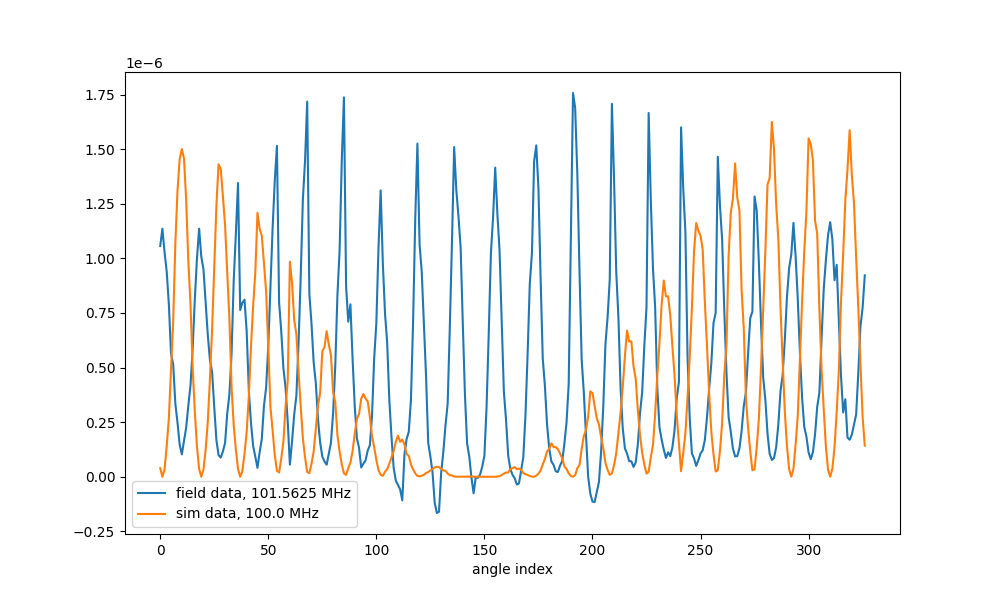

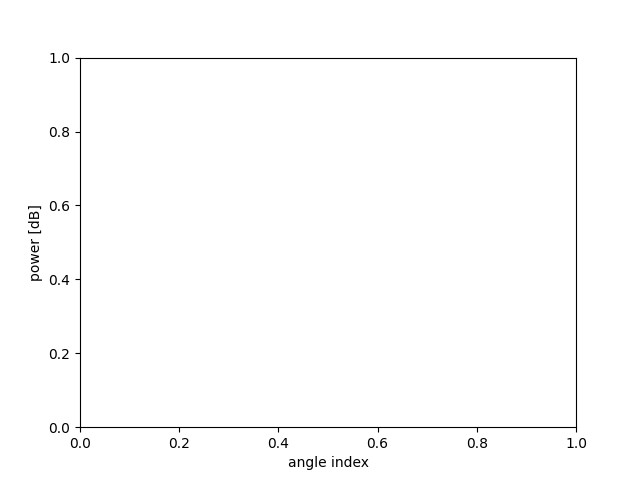

In [33]:
plt.figure(figsize=(10,6))
#plt.plot(10*np.log10(matched_rot[:, 26] * norm[:, 26]), label=f'field data, {freqs[::16][26]} MHz')
plt.plot(matched_rot[:, 26] * norm[:, 26]/1e6, label=f'field data, {freqs[::16][26]} MHz')
plt.plot(10**(matched_sim[:, 50]/10), label=f'sim data, {freqs_sim[50]} MHz')
# plt.plot((matched_rot[:, 26] * norm[:, 26]))
plt.xlabel('angle index')
#plt.ylabel('power [dB]')
plt.legend()
plt.show()
plt.figure()
# plt.plot(10**(matched_sim[:, 50]/10))
# plt.plot((matched_sim[:, 50]))
plt.xlabel('angle index')
plt.ylabel('power [dB]')
plt.show()